# CARVE Tutorial
## Cluster Analysis with Resampling for Validation and Exploration

CARVE is a Python library for stability- and generalizability-based clustering validation. It evaluates clustering robustness by repeatedly subsampling input data, running clustering algorithms on each subsample, building consensus matrices from aligned clustering results, and computing stability and generalizability metrics. CARVE is designed for high-dimensional biological data (e.g., scRNA-seq, genomics) but works with any numerical dataset.

## Table of Contents

1. [Quick Start](#1-quick-start) — Zero to fitted model in 4 code cells
2. [Core Concepts](#2-core-concepts) — Theory and pipeline overview
3. [Running a Full Validation](#3-running-a-full-validation) — Detailed standard workflow
4. [Visualization Gallery](#4-visualization-gallery) — All 5 plot methods
5. [Understanding and Comparing Metrics](#5-understanding-and-comparing-metrics) — When metrics agree and disagree; the k=2 pitfall
6. [Customization & Advanced Usage](#6-customization--advanced-usage) — Custom grids, modes, persistence
7. [Practical Tips & Recipes](#7-practical-tips--recipes) — Choosing parameters and production workflows

### Prerequisites

- Python 3.12
- Install CARVE: `pip install -e .` (from the `code/` directory)
- All examples use synthetic data generated with scikit-learn — no external downloads required

---
## 1. Quick Start

Get from zero to a fitted CARVE model and interpretable plot in under 5 minutes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import multiprocessing

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

from carve import CARVE

It is highly recommended to use parallel processing when using CARVE.

In [2]:
try:
    n_cores = multiprocessing.cpu_count()
except NotImplementedError:
    n_cores = 3

N_JOBS = max(1, n_cores - 1)
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


Combined data shape: (1000, 2)
True clusters: [0 1 2 3]


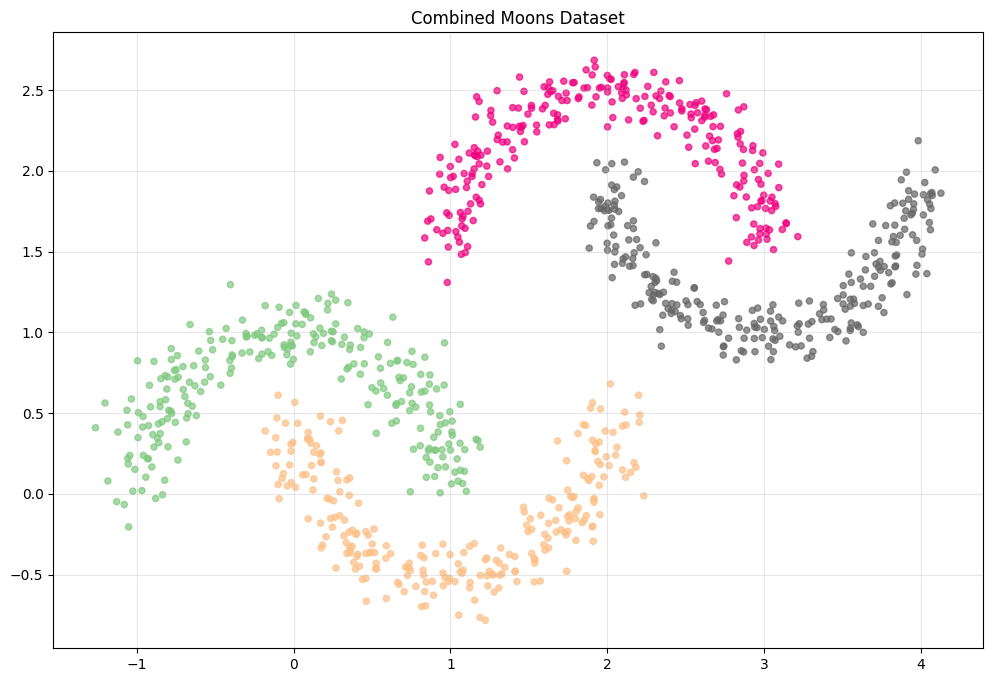

In [ ]:
rng = np.random.default_rng(42)

X1, y1_true = make_moons(n_samples=500, noise=0.12, random_state=42)
X2, y2_true = make_moons(n_samples=500, noise=0.10, random_state=123)
X2 = X2 + np.array([2, 1.5])
y2_true = y2_true + 2

X = np.vstack([X1, X2])
y_true = np.concatenate([y1_true, y2_true])

print(f"Combined data shape: {X.shape}")
print(f"True clusters: {np.unique(y_true)}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="Accent", s=20, alpha=0.7)
plt.title("Combined Moons")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from carve import SpectralClusteringCARVE

# Fit CARVE — evaluate k = 2..6 with 100 resamples
ks = np.arange(2, 6+1)

estimator_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    (SpectralClusteringCARVE, {"n_clusters": ks, "affinity": ["self_tuning"]}),
]

carve = CARVE(
    n_resamples=100, 
    estimator_param_grids=estimator_grids, 
    random_state=42, verbose=0, n_jobs=N_JOBS
)

carve.fit(X, show_progress=True)

Grid configs:   0%|          | 0/10 [00:00<?, ?it/s]

[CARVE] [1/10] est=AgglomerativeClustering n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  
[CARVE] [2/10] est=AgglomerativeClustering n_clusters=3 | ARI_stab=0.715±0.019  ARI_gen=0.630±0.015  
[CARVE] [3/10] est=AgglomerativeClustering n_clusters=4 | ARI_stab=0.645±0.016  ARI_gen=0.552±0.012  
[CARVE] [4/10] est=AgglomerativeClustering n_clusters=5 | ARI_stab=0.646±0.013  ARI_gen=0.520±0.009  
[CARVE] [5/10] est=AgglomerativeClustering n_clusters=6 | ARI_stab=0.700±0.011  ARI_gen=0.545±0.008  
[CARVE] [6/10] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=0.999±0.000  ARI_gen=0.996±0.001  
[CARVE] [7/10] est=SpectralClusteringCARVE n_clusters=3 | ARI_stab=0.909±0.016  ARI_gen=0.701±0.022  
[CARVE] [8/10] est=SpectralClusteringCARVE n_clusters=4 | ARI_stab=0.924±0.005  ARI_gen=0.724±0.011  
[CARVE] [9/10] est=SpectralClusteringCARVE n_clusters=5 | ARI_stab=0.827±0.013  ARI_gen=0.565±0.009  
[CARVE] [10/10] est=SpectralClusteringCARVE n_clusters=6 | ARI_stab=0.775±0.011  A

,n_clusters,"array([ 2, 3..., 8, 9, 10])"
,n_resamples,100
,subsample_ratio,0.8
,estimator_param_grids,"[(<class 'sklea...veClustering'>, ...), (<class 'carve...steringCARVE'>, ...)]"
,normalization_options,None
,dim_reduction_options,None
,reference_labels,None
,n_jobs,10
,random_state,42
,verbose,0


Let's see what CARVE found.

Selected k: 4
ARI vs ground truth: 0.828


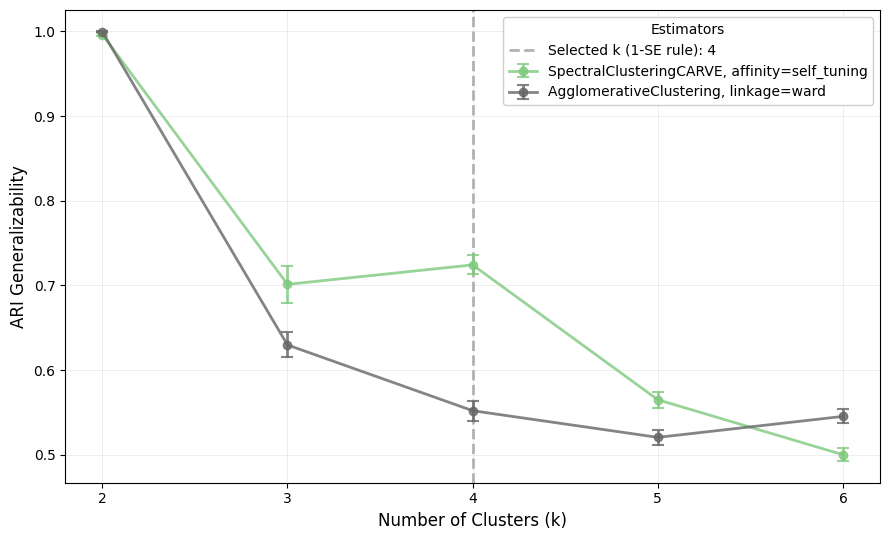

In [5]:
# What is the best k?
best_k = carve.get_k(measure='g', rule='1se', not_two=True)
print(f"Selected k: {best_k}")

# Get cluster labels
labels = carve.get_labels(measure='g', rule='1se', not_two=True)
print(f"ARI vs ground truth: {adjusted_rand_score(y_true, labels):.3f}")

# Plot metric over k
carve.plot_metric_over_n_clusters(measure='g', rule='1se', not_two=True)
plt.show()

The moons clusters creates non-convex clusters that challenge many traditional clustering validation indices like Silhouette. CARVE's resampling based metrics, however, are able to also detect intricate non-linear, non-spherical structures. 

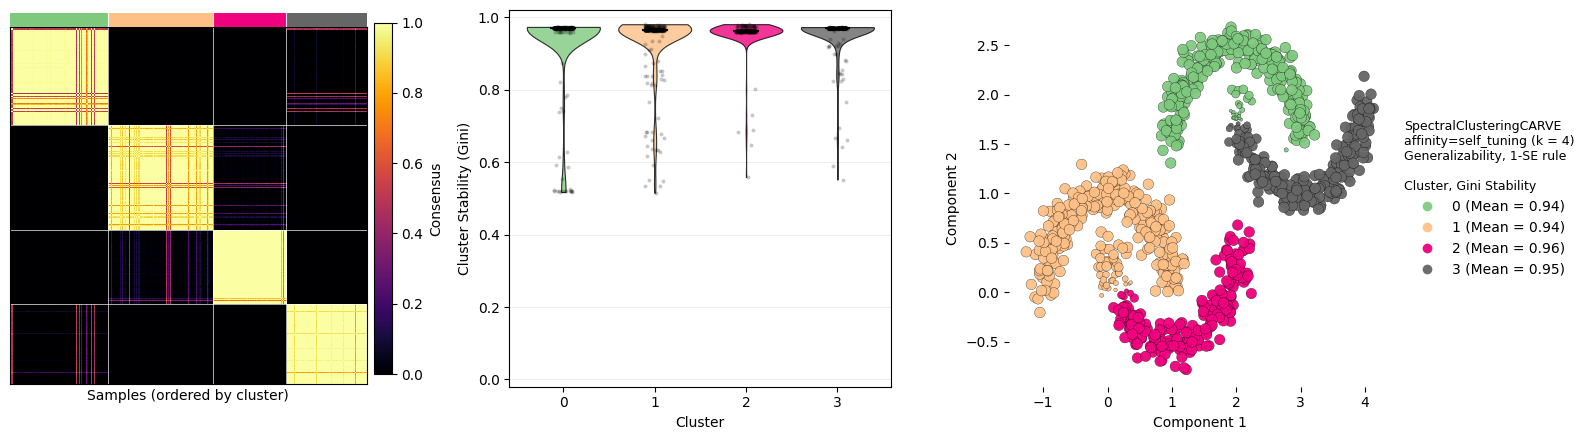

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

carve.plot_consensus_matrix(
    not_two=True,
    ax=axes[0], 
    cmap='inferno'
)

carve.plot_cluster_violin(
    source="gini",
    not_two=True,
    ax=axes[1], 
    annotation=False
)

carve.plot_cluster_scatter(
    not_two=True,
    ax=axes[2]
)

plt.tight_layout()
plt.show()

---
## 2. Core Concepts

### Why Validate Clustering?

Clustering is an ill-defined problem: there is no single "correct" answer, and different algorithms can produce wildly different partitions on the same data. Traditional internal metrics (e.g., silhouette, Davies-Bouldin) favor specific cluster shapes and can be misleading. CARVE instead validates clustering results in terms of:

1. **Stability:** If we slightly perturb the input data, do we get the same clusters?
2. **Generalizability:** Can a classifier trained on the clustering labels predict cluster membership for held-out samples?

### The CARVE Pipeline

For each estimator configuration (estimator type x hyperparameters x *k*), CARVE runs:

1. **Subsample** — draw random subsets of the data (controlled by `subsample_ratio`)
2. **Preprocess** — optionally sample and apply a normalization and/or dimensionality reduction pipeline
3. **Cluster** — run the clustering algorithm on the subsamples
4. **Stability** — compute ARI between the two sets of labels on shared (overlapping) samples
5. **Generalizability** — train a Random Forest on a subsample's labels, predict on the held-out portion, and compute ARI between predicted and original labels

Then:

6. **Consensus matrices** — accumulate co-clustering frequencies across all resamples into an *n* x *n* matrix
7. **Accuracy rates** – record per-sample accuracy scores (after aligning held out and predicted labels)
8. **Summary metrics** — compute PAC, Gini, and cross entropy from the consensus matrix; aggregate ARI scores

Steps 1–5 are repeated `n_resamples` times; steps 6-8 follow as aggregation after bootstrapping.

### Stability Metrics

| Metric | Column Name | Description |
|--------|-------------|-------------|
| **ARI Stability** | `ari_stability` | Mean Adjusted Rand Index between subsamples on their shared samples. Higher = more reproducible. |
| **PAC Stability** | `consensus_pac_stability` | Proportion of Ambiguous Clustering — fraction of consensus matrix entries in [0.1, 0.9]. CARVE reports 1 − PAC so higher is better. |
| **Gini Stability** | `consensus_gini_stability` | Per-sample Gini coefficient of the consensus matrix row. Higher = sample consistently assigned to one cluster. |
| **CE Stability** | `consensus_ce_stability` | Per-sample classification entropy of the consensus matrix row. Higher = sample consistently assigned to one cluster. |

### Generalizability Metrics

| Metric | Column Name | Description |
|--------|-------------|-------------|
| **ARI Generalizability** | `ari_generalizability` | ARI between the Random Forest's predictions on held-out data and the original clustering labels. Higher = clusters are more predictable. |
| **Accuracy Generalizability** | `accuracy_generalizability` | Per-sample accuracy of the Random Forest predictions, aggregated as 1 − misclassification rate. Higher = clusters are more predictable. |

### Selection Rules

After computing metrics for all configurations, CARVE selects the best *k* using one of three rules:

- **`"max"`** — pick the configuration with the highest score. Simple but may overfit and select overly simple yet stable/generalizable clusterings.
- **`"1se"`** — pick the *largest* k whose score is within one standard error of the best score. Inspired by the 1-SE rule in cross-validation for regularized models, this rule tends to weigh off stability/generalizability and interesting clusterings nicely.
- **`"quantile"`** — pick the largest k within the quantile bounds of the best score. Similar to 1-SE but uses empirical quantiles instead of standard errors. Can work well on clustering tasks that give rise to very stable configurations on subsamples. 

### Consensus Matrices

A consensus matrix **M** is an *n* x *n* matrix where M[i, j] records the fraction of resamples in which samples *i* and *j* were assigned to the same cluster (among resamples where both appeared). A perfect clustering produces a block-diagonal matrix with 1s within clusters and 0s between them. Fuzzy off-diagonal blocks indicate instability.

### Combined Metric

**`ari_average`** is the arithmetic mean of `ari_stability` and `ari_generalizability`. It provides a single summary that balances the two. 

---
## 3. Running a Full Validation

This section walks through every parameter and result attribute in detail.

Combined data shape: (500, 2)
True clusters: [0 1 2 3]


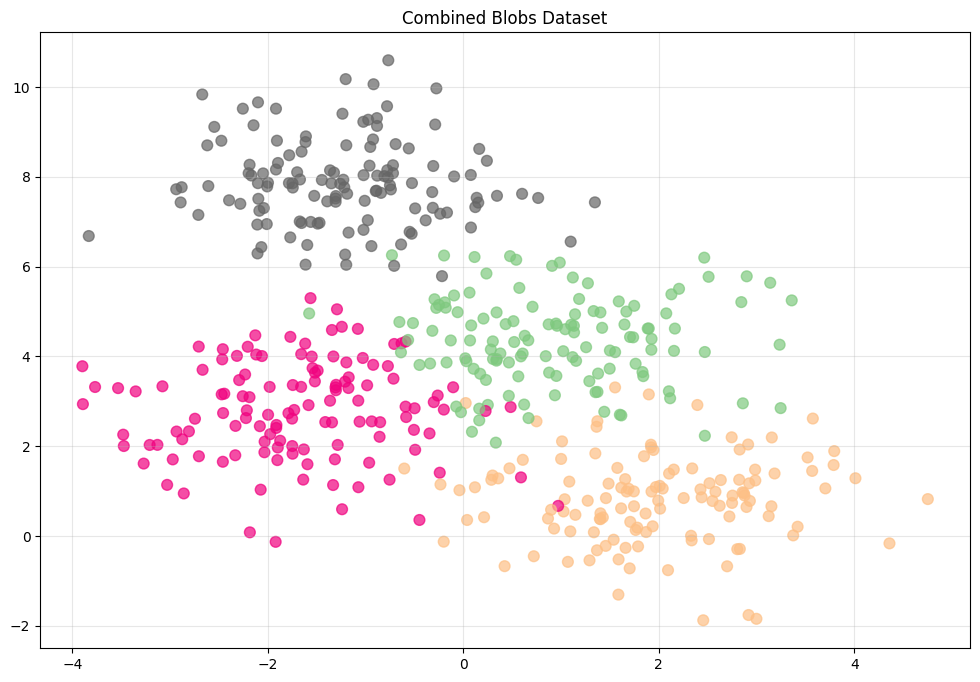

In [8]:
rng = np.random.default_rng(42)

X3, y3_true = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1.0, random_state=0)

print(f"Combined data shape: {X3.shape}")
print(f"True clusters: {np.unique(y3_true)}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X3[:, 0], X3[:, 1], c=y3_true, cmap="Accent", s=60, alpha=0.7)
plt.title("Combined Blobs Dataset")
plt.grid(True, alpha=0.3)
plt.show()

### Constructor Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `n_clusters` | int or ndarray | 10 | Max k (evaluates 2..K), or explicit array of k values |
| `n_resamples` | int | 100 | Number of resampling iterations per configuration |
| `subsample_ratio` | float | 0.8 | Fraction of samples per subsample (0, 1) |
| `estimator_param_grids` | list or None | None | Custom (Estimator, param_grid) tuples; None = defaults |
| `normalization_options` | list or None | None | Custom normalization options; None = defaults |
| `dim_reduction_options` | list or None | None | Custom dim reduction options; None = defaults |
| `reference_labels` | array or None | None | Reference labels for consistent label alignment |
| `n_jobs` | int | 1 | Parallel jobs (-1 = all cores) |
| `random_state` | int or None | None | RNG seed for reproducibility |
| `verbose` | int | 1 | Console output verbosity (0 = silent) |

In [9]:
# Create and fit a CARVE instance with commentary
carve_full = CARVE(
    n_clusters=8,               # Evaluate k = 2, 3, ..., 8 
    n_resamples=120,            # 120 resamples (use >100)
    subsample_ratio=0.8,        # Use 80% of data per subsample (commonly in [0.6, 0.8])
    reference_labels=y3_true,   # We provide reference labels for plotting (note that these are not used to compute any of the metrics)
    n_jobs=N_JOBS,              # Parallel processing (set in Cell 2)
    random_state=42,            # Reproducible results
    verbose=1,                  # Print summary header/footer
)

### `fit()` Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `X` | array-like | *(required)* | Input data matrix (n_samples x n_features) |
| `y` | ignored | None | Included for sklearn compatibility |
| `reference_labels` | array or None | None | Override constructor reference labels |
| `randomize_preprocessing` | bool | False | Randomly sample preprocessing per resample |
| `show_progress` | bool | False | Display a tqdm progress bar |
| `mode` | str | "default" | Run mode: "default", "stability", or "generalizability" |
| `random_state` | int or None | None | Per-call RNG seed override |

In [10]:
carve_full.fit(X3)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 2
[CARVE] n_clusters         : [2 3 4 5 6 7 8]
[CARVE] n_resamples        : 120
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 21
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/21] est=KMeans n_clusters=2 | ARI_stab=0.919±0.006  ARI_gen=0.675±0.026  
[CARVE] [2/21] est=KMeans n_clusters=3 | ARI_stab=0.990±0.002  ARI_gen=0.707±0.016  
[CARVE] [3/21] est=KMeans n_clusters=4 | ARI_stab=0.964±0.002  ARI_gen=0.815±0.008  
[CARVE] [4/21] est=KMeans n_clusters=5 | ARI_stab=0.745±0.008  ARI_gen=0.688±0.007  
[CARVE] [5/21] est=KMeans n_clusters=6 | ARI_stab=0.669±0.010  ARI_gen=0.606±0.009  
[CARVE] [6/21] est=KMeans n_clusters=7 | ARI_stab=0.622±0.009  ARI_g

CARVE(n_clusters=8, n_resamples=120, subsample_ratio=0.8, estimator_param_grids='light', normalization_options=None, dim_reduction_options=None, X_=array([[ 2.63378902e+00,  1.24731812e+00],
       [ 4.35918422e+00, -1.62352163e-01],
       [ 1.02202860e+00,  4.11660348e+00],
       [-1.79912353e-01,  5.08498543e+00],
       [ 7.48740670e-01,  2.55579434e+00],
       [-1.61728602e+00,  4.28547950e+00],
       [ 4.84352668e-01,  2.87328683e+00],
       [ 5.88943261e-01,  4.00148458e+00],
       [ 1.61640160e+00,  2.68683128e+00],
       [-1.02020245e+00,  8.03693996e+00],
       [-2.18696033e+00,  3.09370121e+00],
       [ 1.53774848e+00, -8.11661994e-02],
       [-7.54209176e-01,  1.25628397e+00],
       [-8.07222867e-01,  8.01425288e+00],
       [ 1.92569089e+00,  4.39133857e+00],
       [ 1.27450825e+00,  5.63017322e+00],
       [ 2.92423101e+00,  1.17453557e+00],
       [ 6.64717546e-01,  4.35995267e+00],
       [-2.09657630e+00,  7.50979055e+00],
       [ 1.04278730e+00,  4.60625923e+00],
       [-5.79727632e-02,  4.98538185e+00],
       [ 3.12377692e+00,  4.44277856e-01],
       [-1.90205113e+00,  1.69168607e+00],
       [-1.99794612e+00,  7.86826876e+00],
       [ 1.13277662e+00,  4.53596836e+00],
       [-1.02086300e+00,  6.81872137e+00],
       [ 1.70183577e+00, -7.18810529e-01],
       [-1.30739446e+00,  3.31094520e+00],
       [ 1.53089057e-01,  7.42507822e+00],
       [-3.53111973e+00,  3.29475878e+00],
       [-2.33253052e+00,  1.79957034e+00],
       [-2.97184421e+00,  1.70733927e+00],
       [ 2.82852050e+00, -2.86216980e-01],
       [-5.05113428e-01,  2.36534159e+00],
       [-1.17214632e+00,  3.53476882e+00],
       [ 2.99831361e+00, -1.84201351e+00],
       [-2.10084162e+00,  7.85841977e+00],
       [ 2.50672700e-01,  2.92042337e+00],
       [-2.89122107e+00,  7.42938822e+00],
       [ 2.72165060e+00,  4.36943873e-01],
       [-2.54694250e+00,  9.11153536e+00],
       [ 2.85942078e+00,  2.95602827e+00],
       [ 6.34478531e-02,  5.42080362e+00],
       [ 3.37440440e+00,  1.52448414e-02],
       [-2.03442161e+00,  1.86600216e+00],
       [ 2.93110028e+00,  7.82556191e-01],
       [ 1.60150153e+00,  2.70172967e+00],
       [ 1.55286090e+00,  4.09548857e+00],
       [ 1.02533224e+00,  5.47720295e-01],
       [ 1.70781687e+00,  3.16395183e-01],
       [-1.22719375e+00,  7.93491447e+00],
       [-7.77822630e-01,  8.14690709e+00],
       [-2.18336769e+00,  8.33277561e-02],
       [ 6.22276167e-01,  2.92883603e+00],
       [ 9.08028473e-01,  6.01713005e+00],
       [-1.03920517e-01,  3.31396885e+00],
       [-8.56333563e-01,  2.21037656e+00],
       [-2.19574437e+00,  8.07990347e+00],
       [ 1.34616881e+00,  7.43142772e+00],
       [ 2.00956356e+00,  1.11817132e+00],
       [ 1.92516057e+00,  9.91616889e-01],
       [-1.67291908e+00,  7.00549542e+00],
       [ 1.86461403e+00,  5.02814146e-01],
       [ 1.61607800e+00,  1.07900209e+00],
       [ 1.45661358e+00, -2.18233326e-01],
       [-3.89107783e+00,  2.93821644e+00],
       [-2.76525282e-01,  5.08127768e+00],
       [ 2.10476250e+00,  1.39150044e+00],
       [ 9.59249665e-01,  4.68293906e+00],
       [-2.87482944e+00,  2.15630887e+00],
       [-7.79870540e-01,  9.57133901e+00],
       [ 2.47034915e+00,  4.09862906e+00],
       [-1.23602379e+00,  9.40471963e+00],
       [ 1.77959699e+00,  1.87935694e-01],
       [-2.87562376e-01,  9.16452286e+00],
       [ 1.78753398e+00, -2.30347672e-01],
       [-1.34297852e+00,  2.53239250e+00],
       [-1.91377486e+00,  2.40758952e+00],
       [-3.39637332e-01,  3.84220272e+00],
       [ 1.05472929e-01,  3.72493766e+00],
       [-1.25940139e+00,  7.84695892e+00],
       [ 9.51943954e-01,  3.56575642e+00],
       [-2.04054244e+00,  7.30385411e+00],
       [ 4.65464941e-01,  3.12315514e+00],
       [ 7.08266708e-01,  5.10624372e+00],
       [-1.74644504e+00,  1.83384564e+00],
       [-2.16736922e+00,  8.02821386e+00],
       [-2.36413342e-01,  7.17750897e+00],
       [ 3.15555186e+00,  2.19568563e+00],
       [-1.18836109e+00, 

---
## 4. Visualizations

CARVE provides 5 plot methods. All share a consistent API: `measure`, `rule`, `not_two`, `save`, `show`, `ax`, `figsize`.

### 4.1 `plot_metric_over_n_clusters()`

Line plot showing how a metric varies across k, with one line per estimator configuration. Error bars show +/-1 SE. A vertical dashed line marks the selected k.

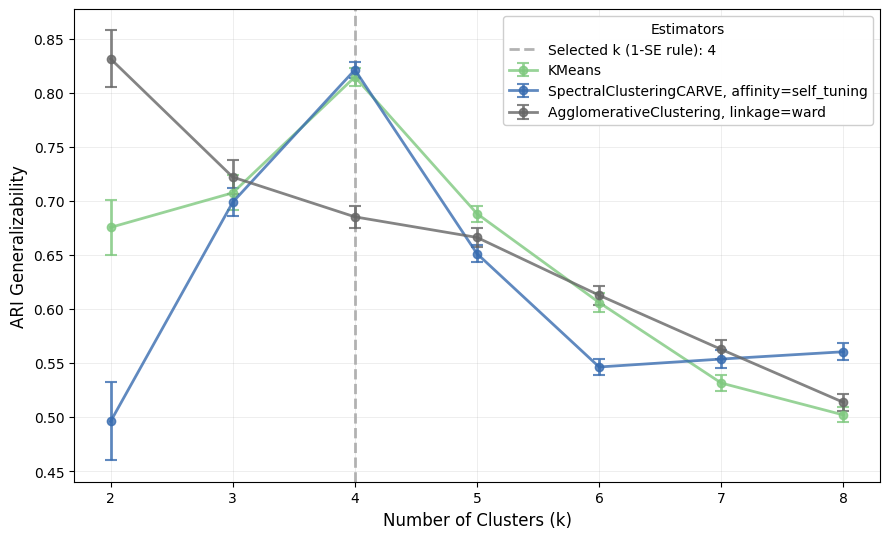

In [11]:
# Basic call — ARI generalizability
carve_full.plot_metric_over_n_clusters()
plt.show()

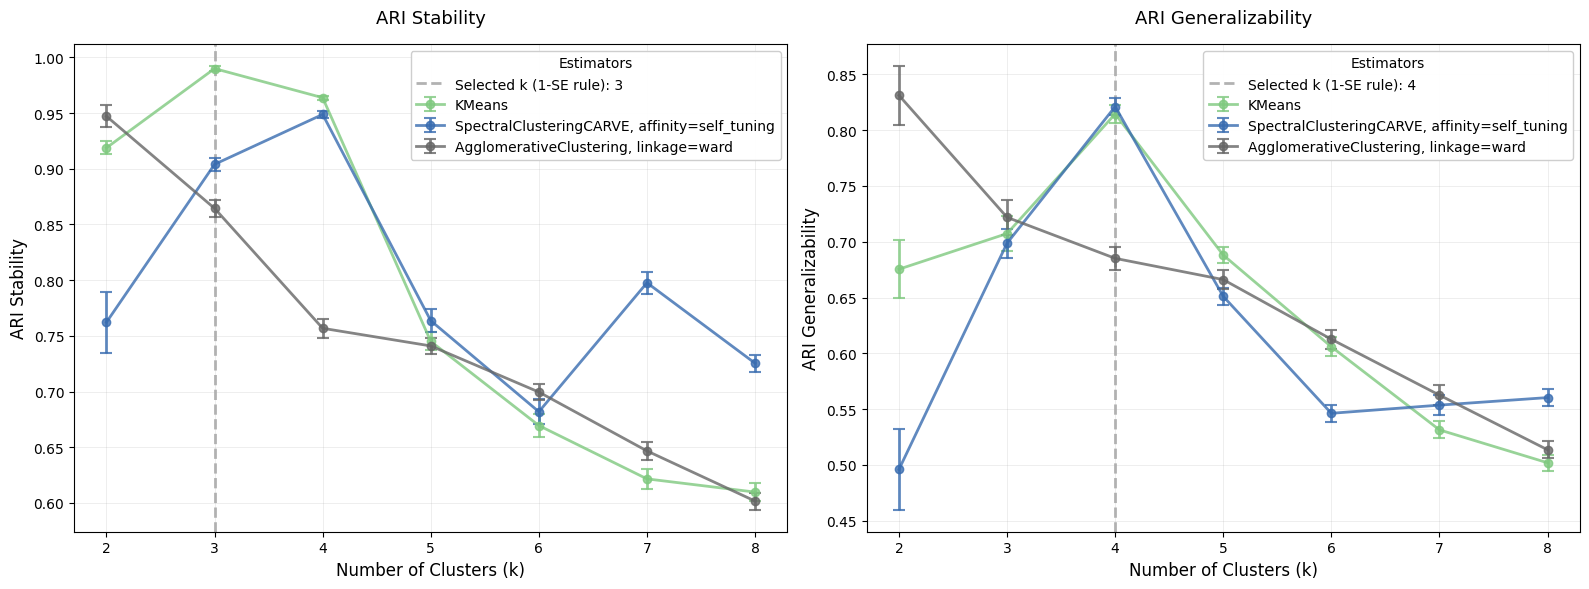

In [12]:
# Side-by-side: stability vs generalizability
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carve_full.plot_metric_over_n_clusters(
    measure="stability", rule="1se", ax=axes[0],
    title="ARI Stability"
)

carve_full.plot_metric_over_n_clusters(
    measure="generalizability", rule="1se", ax=axes[1],
    title="ARI Generalizability"
)

plt.tight_layout()
plt.show()

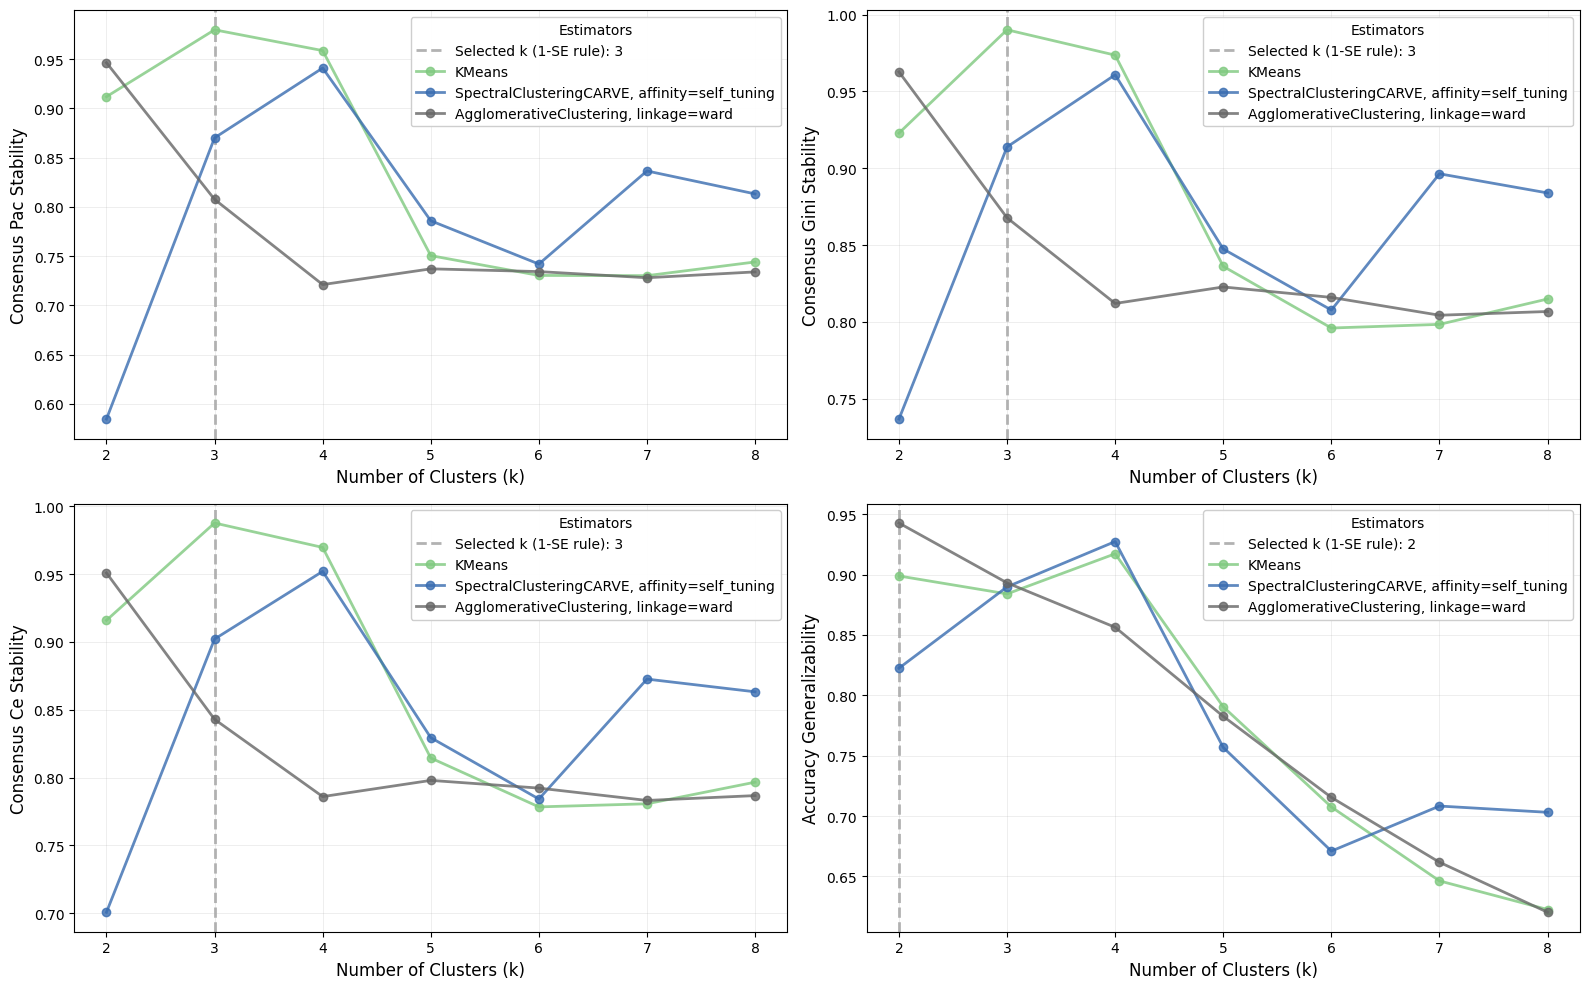

In [ ]:
# Consensus-based metrics: PAC, Gini, CE
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

metrics = ["pac", "gini", "ce", "accuracy"]
for ax, measure in zip(axes, metrics):
    carve_full.plot_metric_over_n_clusters(measure=measure, ax=ax)

plt.tight_layout()
plt.show()

**Interpretation:** Look for a clear peak or plateau. Configurations where all estimators agree on a high score at the same k are strong candidates. Divergence between estimators at a given k suggests the clustering structure is ambiguous at that resolution.

### 4.2 `plot_consensus_matrix()`

Heatmap of the consensus matrix with a cluster-color band on top. Samples are sorted by cluster label so stable clusters appear as crisp diagonal blocks.

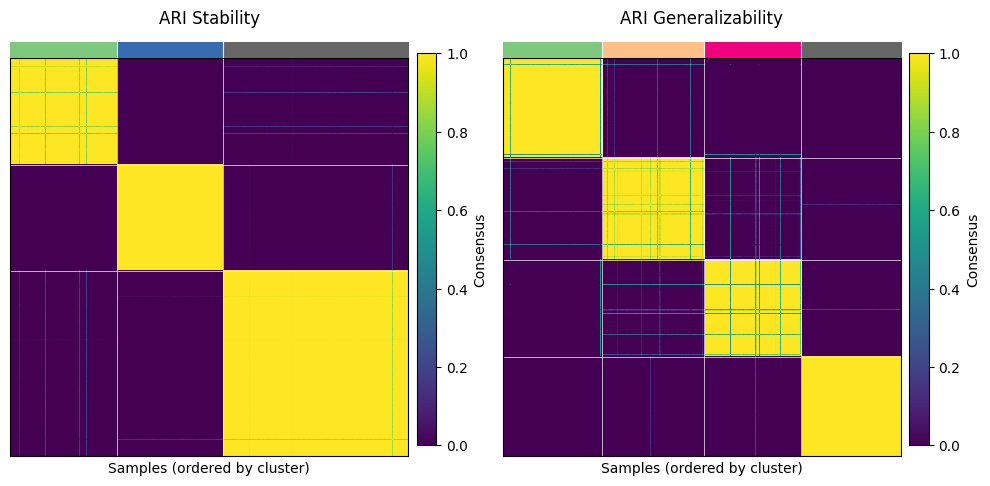

In [41]:
# Side-by-side: stability vs generalizability
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

carve_full.plot_consensus_matrix(
    measure="stability", 
    ax=axes[0],
    title="ARI Stability"
)

carve_full.plot_consensus_matrix(
    measure="generalizability", 
    ax=axes[1],
    title="ARI Generalizability"
)

plt.tight_layout()
plt.show()

**Interpretation:** Crisp, block-diagonal structure = stable clustering. Fuzzy off-diagonal regions = samples that are inconsistently assigned across resamples. Compare consensus matrices at different k values to see how cluster boundaries shift.

### 4.3 `plot_cluster_boxplot()`

Per-cluster distributions of stability or generalizability scores. Three `source` options: `"gini"`, `"ce"`, `"misclassification"`.

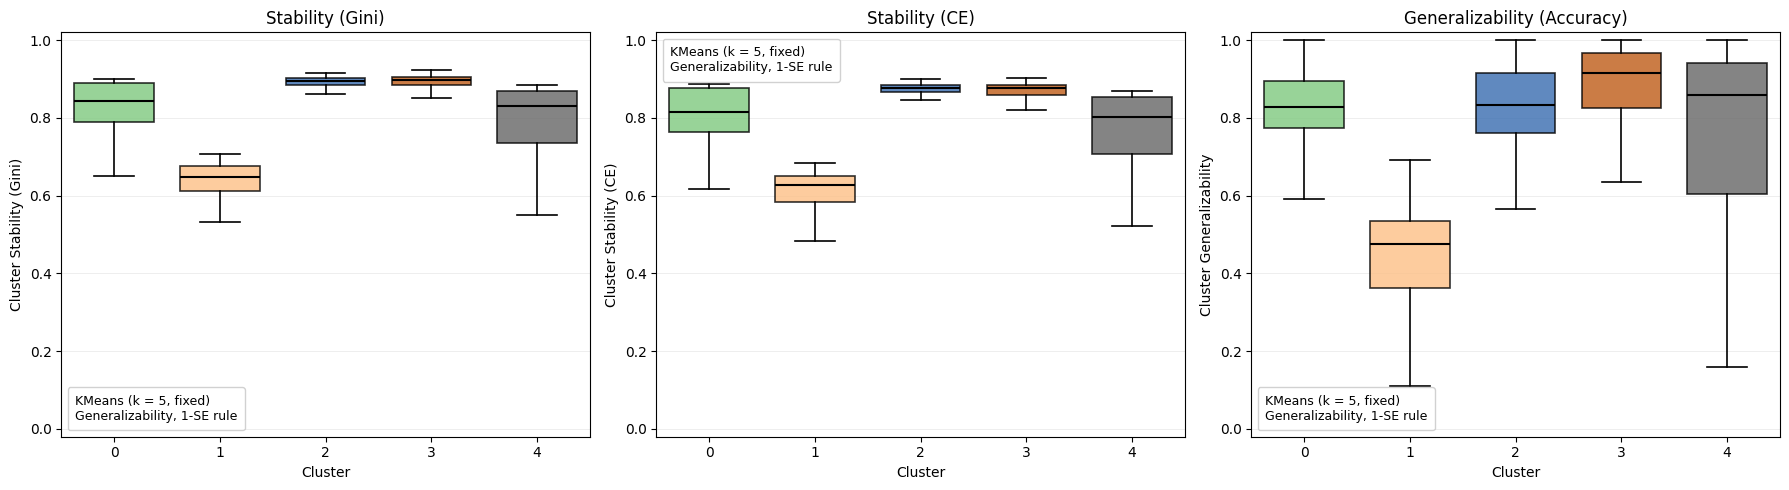

In [15]:
# Side-by-side boxplots for all three sources
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

carve_full.plot_cluster_boxplot(k=5, source="gini", ax=axes[0], title="Stability (Gini)")
carve_full.plot_cluster_boxplot(k=5, source="ce", ax=axes[1], title="Stability (CE)")
carve_full.plot_cluster_boxplot(k=5, source="accuracy", ax=axes[2], title="Generalizability (Accuracy)")

plt.tight_layout()
plt.show()

**Interpretation:** High median + tight spread = well-defined, stable cluster. Low median or wide spread = that cluster is poorly resolved and samples are frequently reassigned.

### 4.4 `plot_cluster_violin()`

Violin plots offer richer distributional detail than boxplots. Customize with `stripplot`, `inner`, and `density_norm`.

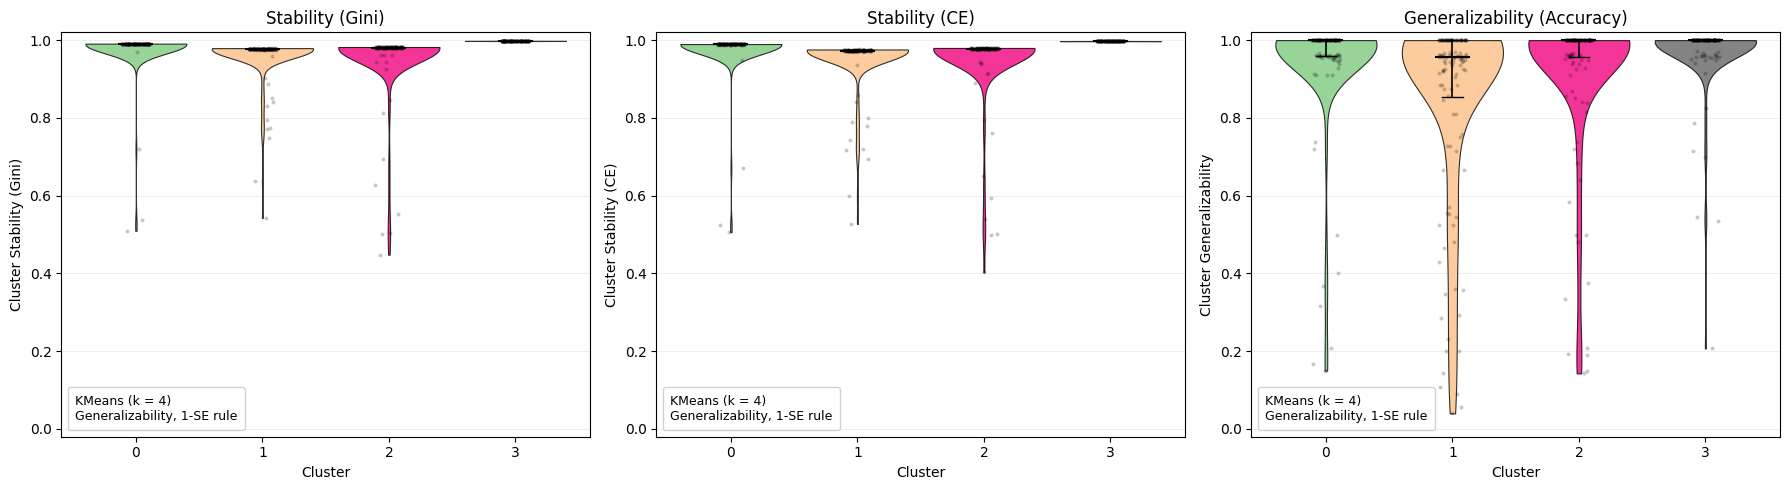

In [16]:
# Side-by-side boxplots for all three sources
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

carve_full.plot_cluster_violin(source="gini", ax=axes[0], title="Stability (Gini)")
carve_full.plot_cluster_violin(source="ce", ax=axes[1], title="Stability (CE)")
carve_full.plot_cluster_violin(source="accuracy", ax=axes[2], title="Generalizability (Accuracy)")

plt.tight_layout()
plt.show()

### 4.5 `plot_cluster_scatter()`

2D scatter plot with score-encoded opacity (cluster-level mean) and marker size (sample-level score). Automatically applies PCA when `p > 2`.

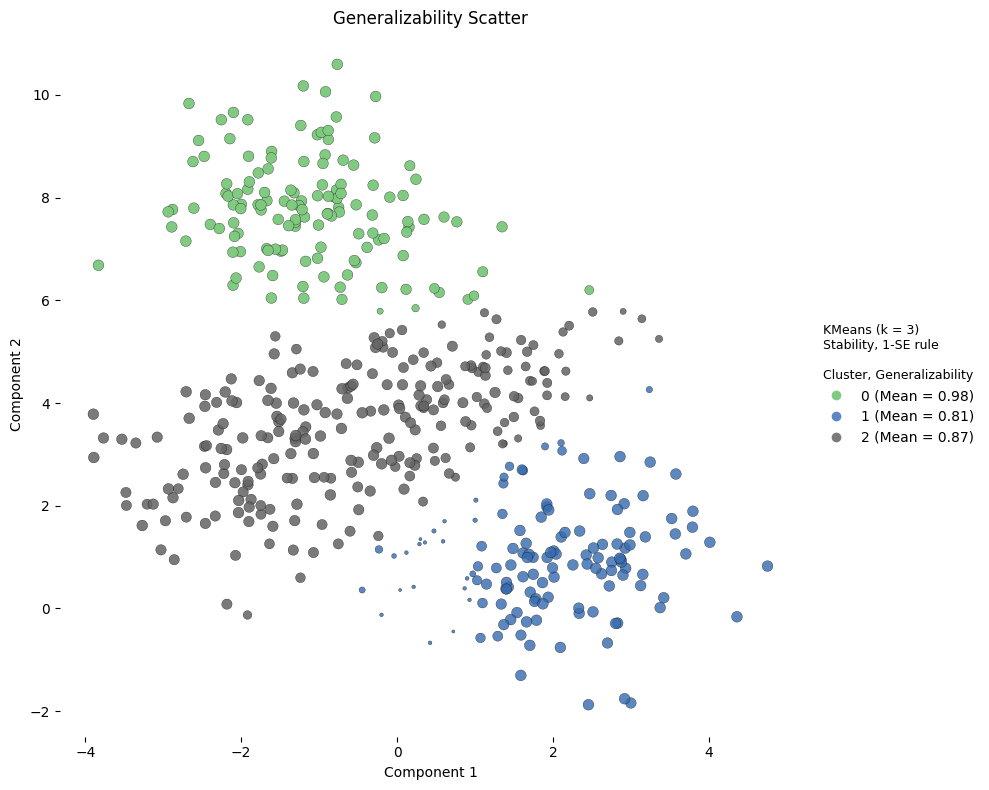

In [17]:
# Default scatter
carve_full.plot_cluster_scatter(
    measure='stability', 
    source="accuracy",
    title="Generalizability Scatter", 
    figsize=(10, 8)
)
plt.show()

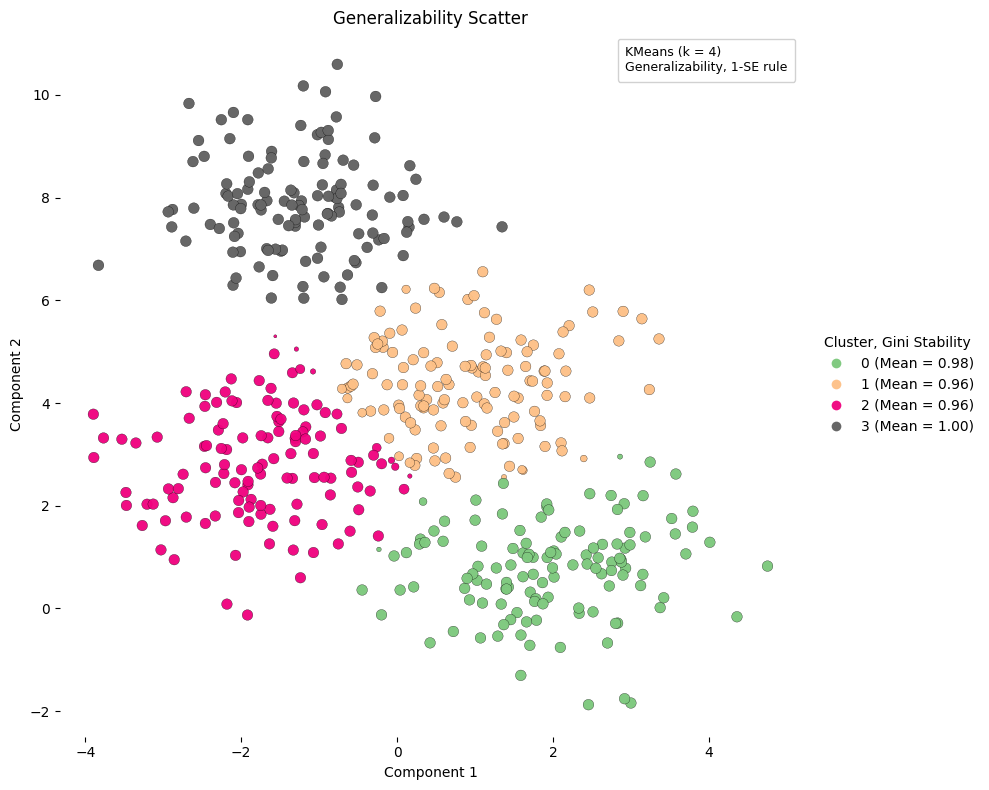

In [18]:
# With box annotation style and misclassification source
carve_full.plot_cluster_scatter(
    measure='generalizability',
    source="gini",
    annotation_style="box",
    title="Generalizability Scatter", 
    figsize=(10, 8)
)

plt.show()

### Saving Plots

All plot methods accept a `save` parameter. When provided, the figure is saved to disk and `None` is returned:

```python
# Save to file (uncomment to use)
# carve_full.plot_metric_over_n_clusters(save="metric_over_k.pdf")
# carve_full.plot_consensus_matrix(save="consensus.png", dpi=150)
```

---
## 5. Exploring `estimator_results_`

After fitting, all results are stored in a DataFrame. Each row represents one estimator configuration (estimator type + hyperparameters + k).

In [19]:
results = carve_full.estimator_results_
print(f"Shape: {results.shape}")
print(f"\nColumns: {list(results.columns)}")
results.head(10)

Shape: (21, 20)

Columns: ['estimator', 'n_clusters', 'ari_stability', 'ari_stability_se', 'ari_stability_upper', 'ari_stability_lower', 'ari_generalizability', 'ari_generalizability_se', 'ari_generalizability_upper', 'ari_generalizability_lower', 'ari_average', 'ari_average_se', 'ari_average_upper', 'ari_average_lower', 'linkage', 'affinity', 'consensus_pac_stability', 'consensus_gini_stability', 'consensus_ce_stability', 'accuracy_generalizability']


,estimator,n_clusters,ari_stability,ari_stability_se,ari_stability_upper,ari_stability_lower,ari_generalizability,ari_generalizability_se,ari_generalizability_upper,ari_generalizability_lower,ari_average,ari_average_se,ari_average_upper,ari_average_lower,linkage,affinity,consensus_pac_stability,consensus_gini_stability,consensus_ce_stability,accuracy_generalizability
0,KMeans,2,0.918757,0.005742,1.000000,0.829837,0.675394,0.025750,1.000000,0.128864,0.797076,0.012918,0.954333,0.528364,NaN,NaN,0.911960,0.922825,0.915940,0.898881
1,KMeans,3,0.989892,0.002296,1.000000,0.959842,0.707334,0.016077,0.907054,0.343320,0.848613,0.008000,0.943940,0.671660,NaN,NaN,0.979888,0.990045,0.987677,0.884022
2,KMeans,4,0.963736,0.001801,1.000000,0.931357,0.814521,0.008134,0.923518,0.624286,0.889128,0.004151,0.944164,0.791662,NaN,NaN,0.958758,0.973548,0.969670,0.917256
3,KMeans,5,0.745035,0.008158,0.943720,0.647113,0.688030,0.007371,0.822470,0.564242,0.716532,0.005689,0.835947,0.626484,NaN,NaN,0.750597,0.836094,0.814429,0.790493
4,KMeans,6,0.669491,0.010446,0.873563,0.497824,0.605854,0.008513,0.753916,0.461619,0.637673,0.007282,0.778777,0.513971,NaN,NaN,0.730461,0.795985,0.778377,0.707553
5,KMeans,7,0.621637,0.009151,0.806246,0.474546,0.531388,0.007624,0.674532,0.405879,0.576513,0.006212,0.697922,0.468303,NaN,NaN,0.730228,0.798362,0.780668,0.646312
6,KMeans,8,0.609781,0.008427,0.766845,0.459287,0.501902,0.006948,0.642885,0.385963,0.555842,0.005492,0.664466,0.455221,NaN,NaN,0.744144,0.814871,0.796595,0.622591
7,AgglomerativeClustering,2,0.947094,0.009892,1.000000,0.859003,0.831219,0.026275,1.000000,-0.067375,0.889157,0.014058,1.000000,0.441740,ward,NaN,0.946485,0.962660,0.950878,0.942737
8,AgglomerativeClustering,3,0.864412,0.007438,0.971800,0.734871,0.721863,0.015466,0.938289,0.374908,0.793137,0.008514,0.918375,0.595913,ward,NaN,0.807687,0.867688,0.842939,0.893153
9,AgglomerativeClustering,4,0.756800,0.008437,0.908004,0.590746,0.685111,0.010384,0.866574,0.503045,0.720955,0.006784,0.840731,0.597770,ward,NaN,0.721162,0.811968,0.785963,0.856371


In [20]:
# Filter to a specific estimator
kmeans_results = results[results["estimator"] == "KMeans"]
print(f"KMeans rows: {len(kmeans_results)}")
kmeans_results[["n_clusters", "ari_stability", "ari_generalizability", "ari_average"]].head()

KMeans rows: 7


,n_clusters,ari_stability,ari_generalizability,ari_average
0,2,0.918757,0.675394,0.797076
1,3,0.989892,0.707334,0.848613
2,4,0.963736,0.814521,0.889128
3,5,0.745035,0.688030,0.716532
4,6,0.669491,0.605854,0.637673


### `get_k()` — Select Best Number of Clusters

Combine any metric with any selection rule:

In [21]:
for measure in ["stability", "generalizability", "average"]:
    for rule in ["max", "1se"]:
        k = carve_full.get_k(measure=measure, rule=rule)
        print(f"  measure={measure:20s}  rule={rule:4s}  =>  k={k}")

  measure=stability             rule=max   =>  k=3
  measure=stability             rule=1se   =>  k=3
  measure=generalizability      rule=max   =>  k=2
  measure=generalizability      rule=1se   =>  k=4
  measure=average               rule=max   =>  k=2
  measure=average               rule=1se   =>  k=4


### `get_labels()` — Retrieve Cluster Assignments

Labels are derived from the consensus matrix of the best configuration. The consensus similarity matrix is converted to a distance matrix and clustered with average-linkage agglomerative clustering.

In [22]:
labels_full = carve_full.get_labels(measure="generalizability", rule="1se")
print(f"Labels shape: {labels_full.shape}")
print(f"Unique labels: {np.unique(labels_full)}")
print(f"ARI vs ground truth: {adjusted_rand_score(y3_true, labels_full):.3f}")

Labels shape: (500,)
Unique labels: [0 1 2 3]
ARI vs ground truth: 0.853


### `get_estimator()` — Inspect Best Configuration

In [23]:
best_est = carve_full.get_estimator(measure="generalizability", rule="1se")
print(f"Best estimator: {best_est}")
print(f"Parameters: {best_est.get_params()}")

Best estimator: KMeans(n_clusters=np.int64(4))
Parameters: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': np.int64(4), 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


### Fixed-k Override

You can override the automatic selection and request labels for a specific k:

In [24]:
labels_k3 = carve_full.get_labels(k=3)
labels_k5 = carve_full.get_labels(k=5)

print(f"k=3: ARI={adjusted_rand_score(y3_true, labels_k3):.3f}, unique={np.unique(labels_k3)}")
print(f"k=5: ARI={adjusted_rand_score(y3_true, labels_k5):.3f}, unique={np.unique(labels_k5)}")

k=3: ARI=0.637, unique=[0 1 2]
k=5: ARI=0.837, unique=[0 1 2 3 4]


---
## 6. Understanding and Comparing Metrics

This section explores when different metrics agree or disagree, and how selection rules affect the outcome.

### Metric Aliases

CARVE accepts short aliases for metric names. The full mapping:

| Alias | Full Column Name |
|-------|------------------|
| `"s"`, `"stab"`, `"stability"` | `ari_stability` |
| `"g"`, `"gen"`, `"generalizability"` | `ari_generalizability` |
| `"avg"`, `"average"` | `ari_average` |
| `"pac"` | `consensus_pac_stability` |
| `"gini"` | `consensus_gini_stability` |
| `"ce"` | `consensus_ce_stability` |
| `"misclass"`, `"misclassification"` | `misclassification_generalizability` |

### Easy vs Hard: When Metrics Agree and Disagree

We create two datasets — one well-separated, one heavily overlapping — and compare how metrics behave.

In [25]:
# Easy: well-separated clusters
X_easy, y_easy = make_blobs(
    n_samples=500, n_features=2, centers=3,
    cluster_std=0.8, random_state=3,
)

# Hard: heavily overlapping clusters
X_hard, y_hard = make_blobs(
    n_samples=500, n_features=2, centers=3,
    cluster_std=2.3, random_state=10,
)

print(f"Easy data: {X_easy.shape}")
print(f"Hard data: {X_hard.shape}")

Easy data: (500, 2)
Hard data: (500, 2)


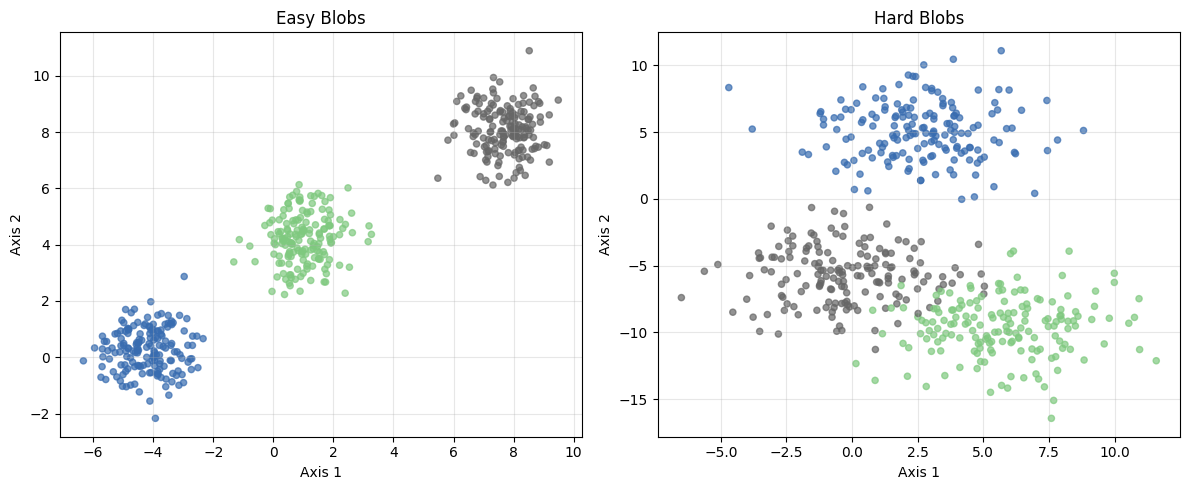

In [26]:
# PCA view of easy vs hard blobs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X, y, label in [
    (axes[0], X_easy, y_easy, "Easy Blobs"),
    (axes[1], X_hard, y_hard, "Hard Blobs"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="Accent", s=20, alpha=0.7)
    ax.set_xlabel(f"Axis 1")
    ax.set_ylabel(f"Axis 2")
    ax.set_title(f"{label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
estimator_grids = [
    (KMeans, {"n_clusters": ks}),
    (SpectralClusteringCARVE, {"n_clusters": ks, "affinity": ["self_tuning"]}),
]

carve_easy = CARVE(n_clusters=6, estimator_param_grids=estimator_grids, n_jobs=N_JOBS, random_state=42, verbose=1)
carve_easy.fit(X_easy)

print('\n')

carve_hard = CARVE(n_clusters=6, estimator_param_grids=estimator_grids, n_jobs=N_JOBS, random_state=42, verbose=1)
carve_hard.fit(X_hard)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 2
[CARVE] n_clusters         : [2 3 4 5 6]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 10
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/10] est=KMeans n_clusters=2 | ARI_stab=0.838±0.033  ARI_gen=0.807±0.035  
[CARVE] [2/10] est=KMeans n_clusters=3 | ARI_stab=1.000±0.000  ARI_gen=0.992±0.001  
[CARVE] [3/10] est=KMeans n_clusters=4 | ARI_stab=0.798±0.010  ARI_gen=0.860±0.004  
[CARVE] [4/10] est=KMeans n_clusters=5 | ARI_stab=0.677±0.013  ARI_gen=0.697±0.010  
[CARVE] [5/10] est=KMeans n_clusters=6 | ARI_stab=0.629±0.011  ARI_gen=0.609±0.009  
[CARVE] [6/10] est=SpectralClusteringCARVE n_clusters=2 | ARI_stab=0.696

,n_clusters,6
,n_resamples,100
,subsample_ratio,0.8
,estimator_param_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'carve...steringCARVE'>, ...)]"
,normalization_options,None
,dim_reduction_options,None
,reference_labels,None
,n_jobs,10
,random_state,42
,verbose,1


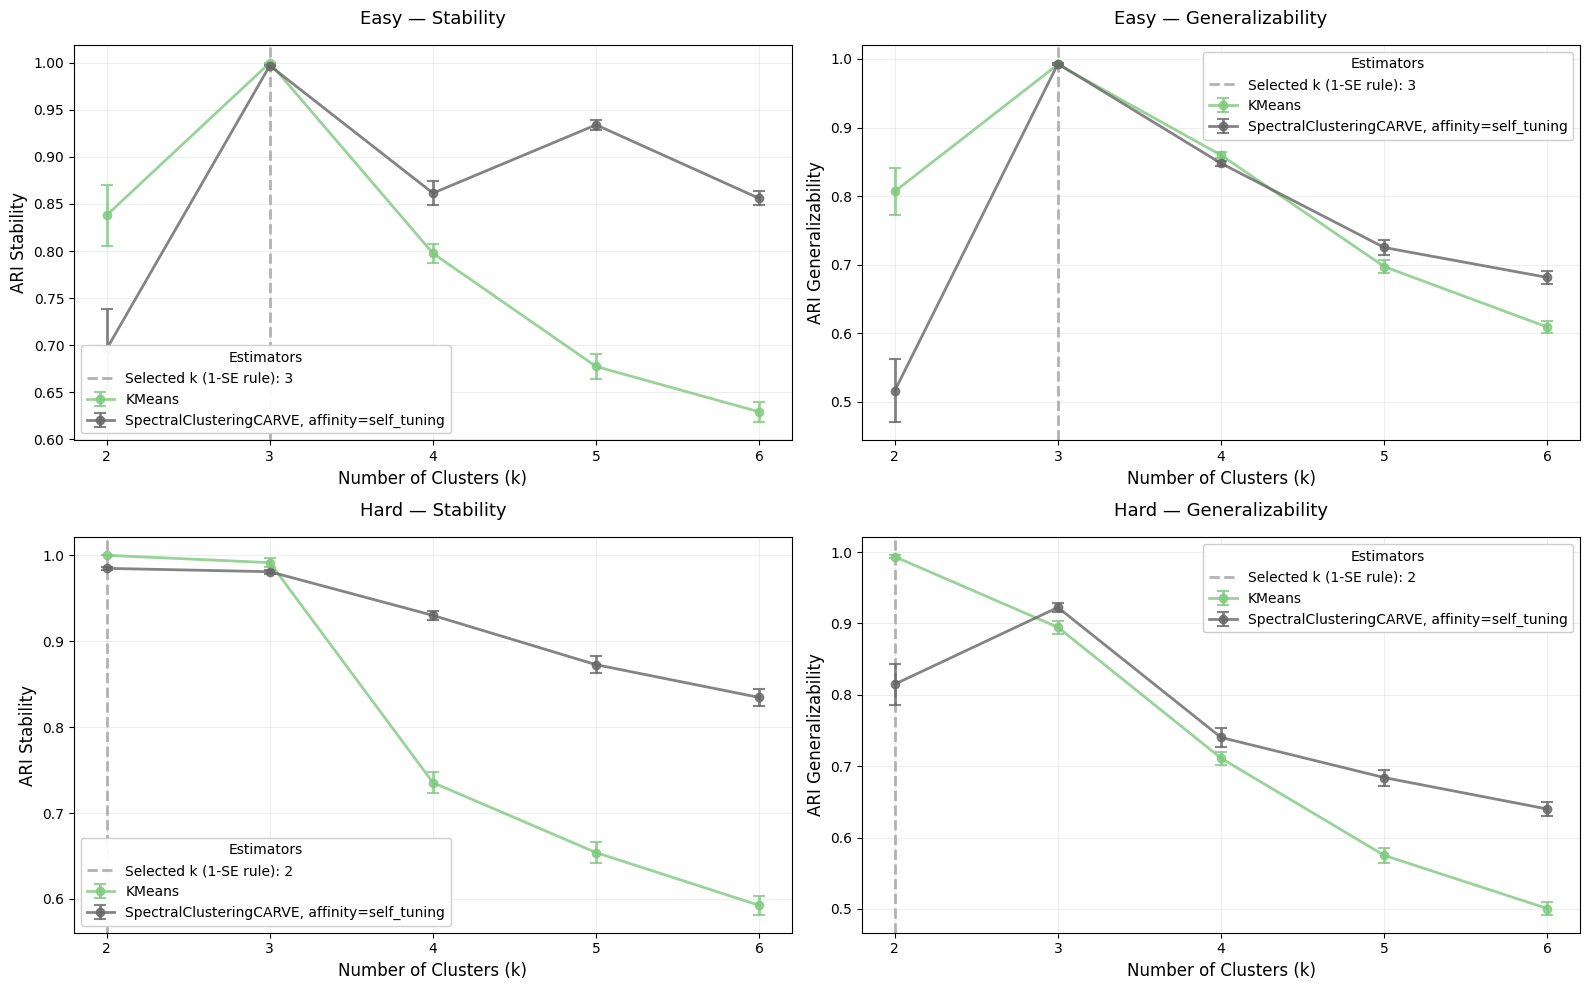

In [28]:
# Compare metric plots side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

carve_easy.plot_metric_over_n_clusters(
    measure="stability", ax=axes[0, 0],
    title="Easy — Stability"
)

carve_easy.plot_metric_over_n_clusters(
    measure="generalizability", ax=axes[0, 1],
    title="Easy — Generalizability"
)

carve_hard.plot_metric_over_n_clusters(
    measure="stability", ax=axes[1, 0],
    title="Hard — Stability"
)

carve_hard.plot_metric_over_n_clusters(
    measure="generalizability", ax=axes[1, 1],
    title="Hard — Generalizability"
)

plt.tight_layout()
plt.show()

**Interpretation:**
- **Easy data:** All metrics should peak at k=3 with high scores. Stability and generalizability agree.
- **Hard data:** Metrics are lower overall and may peak at different k values. Stability might favor fewer clusters (merging overlapping groups) while generalizability might favor the true k if the classifier can separate them. Disagreement between metrics is informative — it suggests the clustering structure is ambiguous.

### Direct DataFrame Manipulation

The results DataFrame supports standard pandas operations:

In [29]:
# Mean stability by k, averaged across estimators
results_easy = carve_easy.estimator_results_
(
    results_easy
    .groupby("n_clusters")[["ari_stability", "ari_generalizability", "ari_average"]]
    .mean()
    .round(3)
)

,ari_stability,ari_generalizability,ari_average
n_clusters,,,
2,0.767,0.662,0.714
3,0.998,0.992,0.995
4,0.830,0.854,0.842
5,0.806,0.711,0.758
6,0.742,0.645,0.694


In [30]:
# Top 5 configurations by average ARI
(
    results_easy
    .nlargest(5, "ari_stability")
    [["estimator", "n_clusters", "ari_stability", "ari_generalizability", "ari_average"]]
)

,estimator,n_clusters,ari_stability,ari_generalizability,ari_average
1,KMeans,3,1.000000,0.991995,0.995997
6,SpectralClusteringCARVE,3,0.996981,0.992896,0.994939
8,SpectralClusteringCARVE,5,0.934091,0.725072,0.829581
7,SpectralClusteringCARVE,4,0.861503,0.847760,0.854631
9,SpectralClusteringCARVE,6,0.855905,0.681409,0.768657


### Selection Rules Comparison

How do the three rules differ on the same data?

In [31]:
print("Generalizability-based k selection:")

for rule in ["max", "1se", "quantile"]:
    k_easy = carve_easy.get_k(measure="generalizability", rule=rule)
    k_hard = carve_hard.get_k(measure="generalizability", rule=rule)
    print(f"  rule={rule:10s}  =>  easy k={k_easy}, hard k={k_hard}")
    
print('\n')    

print("Stability-based k selection:")

for rule in ["max", "1se", "quantile"]:
    k_easy = carve_easy.get_k(measure="stability", rule=rule)
    k_hard = carve_hard.get_k(measure="stability", rule=rule)
    print(f"  rule={rule:10s}  =>  easy k={k_easy}, hard k={k_hard}")

Generalizability-based k selection:
  rule=max         =>  easy k=3, hard k=2
  rule=1se         =>  easy k=3, hard k=2
  rule=quantile    =>  easy k=3, hard k=2


Stability-based k selection:
  rule=max         =>  easy k=3, hard k=2
  rule=1se         =>  easy k=3, hard k=2
  rule=quantile    =>  easy k=3, hard k=2


### The k=2 Pitfall and `not_two`

A common issue in clustering validation with stability and generalizability: clusterings with k=2 are often very stable and generalizable even when the data has more clusters. Most datasets can be trivially split into two groups — and because a two-way split is simple, it tends to produce high stability/generalizability and clean consensus matrices. But it's usually uninformative.

CARVE provides `not_two=True` to skip k=2 during selection, revealing the more meaningful partition underneath. Let's see this in action with some circular clusters.

In [32]:
X_circ_a, y_circ_a = make_circles(
    n_samples=500,
    factor=0.3,
    noise=0.05,
    random_state=42
)

X_circ_b, y_circ_b = make_circles(
    n_samples=500,
    factor=0.0,
    noise=0.12,
    random_state=123
)

X_circ_b = X_circ_b + np.array([2.2, 1.2])

X_circ = np.vstack([X_circ_a, X_circ_b])
y_circ = np.concatenate([y_circ_a, y_circ_b + 2])

print(f"X_circ shape: {X_circ.shape}")
print(f"Unique labels in y_circ: {np.unique(y_circ)}")

X_circ shape: (1000, 2)
Unique labels in y_circ: [0 1 2 3]


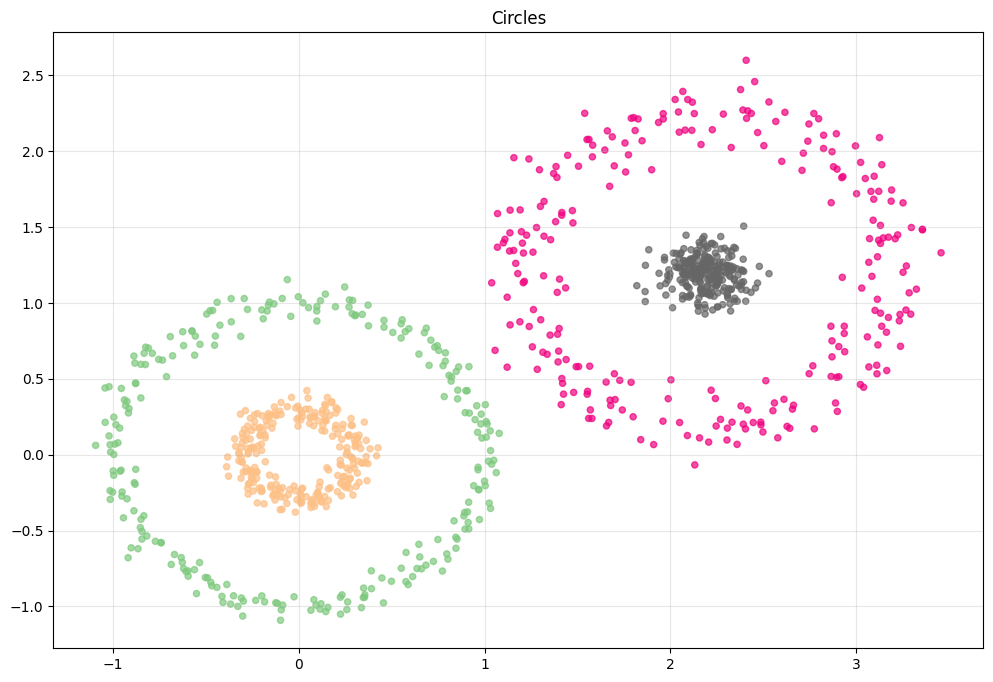

In [33]:
plt.figure(figsize=(12, 8))
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="Accent", s=20, alpha=0.7)
plt.title("Circles")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Fit CARVE on data
carve_circ = CARVE(n_clusters=6, n_jobs=N_JOBS, random_state=42, verbose=0)
carve_circ.fit(X_circ, show_progress=True)

NameError: name 'X8' is not defined

In [ ]:
k_default = carve_circ.get_k(measure="stability", rule="1se")
k_not_two = carve_circ.get_k(measure="stability", rule="1se", not_two=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carve_circ.plot_metric_over_n_clusters(
    measure="stability",
    rule="1se",
    ax=axes[0],
    title=f"Default selection (k={k_default})"
)

carve_circ.plot_metric_over_n_clusters(
    measure="stability",
    rule="1se",
    not_two=True,
    ax=axes[1],
    title=f"not_two=True selection (k={k_not_two})"
)

plt.tight_layout()
plt.show()

print(f"Selected k (default): {k_default}")
print(f"Selected k (not_two=True): {k_not_two}")

In [ ]:
# Side-by-side: k=2 vs not_two-selected k
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5))

carve_circ.plot_consensus_matrix(
    measure="stability", rule="1se", 
    cmap="inferno", ax=axes[0],
    title="Consensus Matrix at k=2"
)

carve_circ.plot_consensus_matrix(
    measure="stability", rule="1se", not_two=True, 
    cmap="inferno", ax=axes[1],
    title=f"Consensus Matrix at k={k_not_two} (not_two)"
)

plt.tight_layout()
plt.show()

The k=2 consensus matrix looks deceptively clean — four clusters arranged along a line can always be split at the midpoint into two stable groups. But this tells us nothing about the real structure. With `not_two=True`, CARVE skips the trivial binary split and selects a more informative partition that better reflects the underlying clusters.

Recommendation: Use `not_two=True` whenever k=2 might represent a trivial split rather than genuine two-cluster structure. 

In [ ]:
carve_circ.plot_cluster_scatter(measure="stability", rule="1se", not_two=True, figsize=(12, 8))
plt.show()

---
## 7. Customization & Advanced Usage

### 7.1 Custom Estimator Grids

By default, CARVE evaluates KMeans, AgglomerativeClustering (ward), and SpectralClustering. You can restrict or extend this:

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

ks = list(range(2, 7))
custom_grids = [
    (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "complete", "average", "single"]}),
]

carve_custom = CARVE(
    estimator_param_grids=custom_grids,
    n_resamples=20,
    n_jobs=N_JOBS,
    random_state=42,
    verbose=0,
)
carve_custom.fit(X3, show_progress=True)

print(f"Configurations evaluated: {len(carve_custom.estimator_results_)}")
print(f"Estimators: {carve_custom.estimator_results_['estimator'].unique()}")
print(f"Best k (stability): {carve_custom.get_k(measure='stability')}")

# Plot metric by estimator
carve_custom.plot_metric_over_n_clusters(measure='stability', rule='1se')
plt.show()

### 7.2 Run Modes

By default, CARVE computes both stability and generalizability. Use `mode="stability"` to skip generalizability (faster) or `mode="generalizability"` to skip stability. 

(**Note that this is an experimental feature and may break some functionality.**)

In [ ]:
# Stability-only mode
carve_stab = CARVE(n_clusters=6, n_resamples=20, n_jobs=N_JOBS, random_state=42, verbose=0)
carve_stab.fit(X3, mode="stability", show_progress=True)

# Generalizability metrics will be NaN
results_stab = carve_stab.estimator_results_
print("Generalizability columns (all NaN in stability mode):")
print(results_stab[["ari_generalizability", "misclassification_generalizability"]].head())

### 7.3 Persistence — `save()` and `load()`

Save fitted CARVE instances to disk and reload them later.

In [ ]:
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    path_no_data = os.path.join(tmpdir, "results.carve")
    path_with_data = os.path.join(tmpdir, "results_with_data.carve")

    # Save without data (default) — smaller file
    carve_full.save(path_no_data)
    size_no_data = os.path.getsize(path_no_data)

    # Save with data — needed for scatter plots after loading
    carve_full.save(path_with_data, include_data=True)
    size_with_data = os.path.getsize(path_with_data)

    print(f"Without data: {size_no_data / 1024:.1f} KB")
    print(f"With data:    {size_with_data / 1024:.1f} KB")

    # Load and verify
    loaded = CARVE.load(path_with_data)
    print(f"\nLoaded k: {loaded.get_k()}")
    print(f"Labels match: {np.array_equal(loaded.get_labels(), carve_full.get_labels())}")

**Note:** If you save without `include_data=True`, the `plot_cluster_scatter()` method will raise an error unless you re-supply `X` explicitly:

```python
loaded = CARVE.load("results.carve")  # saved without data
loaded.plot_cluster_scatter(X=X_full)  # pass X explicitly
```

### 7.4 Reference Labels

By default, CARVE may assign different integer labels across successive `get_labels()` calls (e.g., what was cluster 0 might become cluster 2). Use `reference_labels` to enforce consistent alignment:

In [ ]:
# Use ground truth as reference for consistent alignment
carve_ref = CARVE(n_clusters=6, n_resamples=20, n_jobs=N_JOBS, random_state=42, verbose=0)
carve_ref.fit(X3, reference_labels=y, show_progress=True)

labels_ref = carve_ref.get_labels()
print(f"ARI vs ground truth: {adjusted_rand_score(y, labels_ref):.3f}")
print("Labels are aligned to reference: cluster IDs match ground truth ordering")

---
## 8. Practical Tips & Recipes

### Which Metric to Use?

|  |  |  |
|----------|-------------------|-----|
| Resampling generalizability | `"generalizability"` | Ensures clusters are learnable (*) |
| Resampling stability | `"stability"` | Focuses on reproducibility |
| Consensus based | `"gini"` or `"ce"` | Very similalr to stability, provide per-sample resolution |
| Misclassification based | `"accuracy"` | Very similalr to generalizability; provide per-sample reolustion |
|–––––––––|–––––––––|–––––––––|
| Misc.: |  |
| Consensus based | `"pac"` | Very similalr to stability |
| General-purpose | `"average"` (or `"avg"`) | Balances stability and generalizability |

(*) _Generalizability & the 1-SE rule performed best in benchmarking and are thus our default recommendation._

### Parallelization

CARVE supports parallel execution via joblib:

```python
carve = CARVE(n_clusters=10, n_resamples=100, n_jobs=8)  # use 8 cores
carve.fit(X)
```

Speedup is near-linear with the number of cores for large `n_resamples`.

### Computational Cost

The total number of clustering fits equals:

```
n_configs = (n_estimator_configs) x (n_k_values)
n_total_fits = n_configs x n_resamples
```

With defaults (KMeans + Agglomerative + SpectralClustering = 3 estimators, k=2..10 = 9 values, 100 resamples), that's 3 x 9 x 100 = 2,700 fits.

**Strategies to reduce cost:**
- Reduce `n_clusters` to a narrower range (e.g., `np.arange(2, 6)` instead of 10)
- Use custom `estimator_param_grids` with fewer estimators
- Lower `n_resamples` for exploration
- Increase `n_jobs` for parallelism

### Timing Example

In [ ]:
import time

# Minimal grid for timing
timing_grids = [
    (KMeans, {"n_clusters": [2, 3, 4, 5]}),
]

carve_timing = CARVE(
    estimator_param_grids=timing_grids,
    n_resamples=100,
    n_jobs=N_JOBS,
    random_state=42,
    verbose=0,
)

t0 = time.time()
carve_timing.fit(X3)
elapsed = time.time() - t0

n_configs = len(carve_timing.estimator_results_)
print(f"Configs: {n_configs}, Resamples: 100, Total fits: {n_configs * 100}")
print(f"Wall time: {elapsed:.1f}s ({elapsed / (n_configs * 100) * 1000:.1f} ms/fit)")

### Example Workflow

A complete end-to-end workflow in one cell:

In [ ]:
# --- 1. Generate data ---
X_prod, y_prod = make_blobs(
    n_samples=400, n_features=10, centers=5,
    cluster_std=8.0, random_state=99,
)

# Add uninformative noise dimensions
rng_prod = np.random.default_rng(99)
X_prod = np.hstack([X_prod, rng_prod.standard_normal((400, 50))])

# Quick PCA peek at the data
pca = PCA(n_components=2)
X_prod_pca = pca.fit_transform(X_prod)
plt.figure(figsize=(7, 4.5))
plt.scatter(X_prod_pca[:, 0], X_prod_pca[:, 1], c=y_prod, cmap="Accent", s=20, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("Noisy Data")
plt.grid(True, alpha=0.3)
plt.show()

# --- 2. Fit CARVE ---
carve_prod = CARVE(n_clusters=8, n_resamples=25, n_jobs=N_JOBS, random_state=42, verbose=0)
carve_prod.fit(X_prod, show_progress=True)

# --- 3. Select best k and labels ---
best_k = carve_prod.get_k(measure="stability", rule="1se")
labels_prod = carve_prod.get_labels(measure="stability", rule="1se")
print(f"Selected k={best_k}, ARI={adjusted_rand_score(y_prod, labels_prod):.3f}")

# --- 4. Visualization panel ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

carve_prod.plot_metric_over_n_clusters(
    measure="stability", ax=axes[0, 0],
    title="Stability over k"
)

carve_prod.plot_consensus_matrix(
    measure="stability", 
    cmap="inferno", ax=axes[0, 1],
    title="Consensus Matrix"
)

carve_prod.plot_cluster_violin(
    measure="stability", source="gini", 
    ax=axes[1, 0],
    title="Gini Stability by Cluster"
)

carve_prod.plot_cluster_scatter(
    measure="stability", 
    ax=axes[1, 1],
    title="Cluster Scatter"
)

plt.tight_layout()
plt.show()

---